# Visualization of Gaussian Noise Added Example

In [43]:
import warnings
## filter out all warnings
warnings.filterwarnings('ignore')

import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2024)

## Loading Packages

## Loading Data

In [ ]:
adata = sc.read_h5ad('../../Noise_Combination_1.h5ad')
adata = adata[adata.obs['noise_level']==0]

In [49]:
adata

View of AnnData object with n_obs × n_vars = 1200 × 0
    obs: 'Ground Truth', 'noise_level', 'SpaGCN', 'SpatialGlue', 'MultiMAP', 'STAGATE', 'Modality1', 'Modality2', 'SpatialCOC', 'MultiVI', 'COSMOS'
    obsm: 'COSMOS', 'Modality1', 'Modality2', 'MultiMAP', 'MultiVI', 'STAGATE', 'SpatialCOC', 'SpatialGlue', 'spatial'

## Adding Noise

In [52]:
adata.obs['Noise_Added'] = adata.obs['Ground Truth'].astype('category').copy()

categories = adata.obs['Noise_Added'].cat.categories.tolist()
categories.append('e')
adata.obs['Noise_Added'] = adata.obs['Noise_Added'].cat.set_categories(categories)

random_indices = np.random.choice(adata.obs_names, size=250, replace=False)
adata.obs.loc[random_indices, 'Noise_Added'] = 'e'

## Ploting 

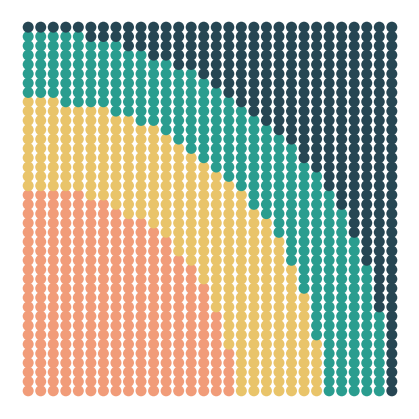

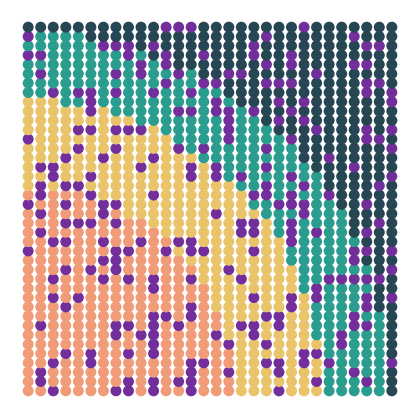

In [58]:
colors = ['#f19c79', '#e9c46a', '#2a9d8f', '#264653', '#722E9A']

# Fig 1: Ground Truth
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
sc.pl.embedding(adata, basis='spatial', color=['Ground Truth'], title=None, s=250, 
                colorbar_loc=None, show=False, ax=ax, palette=colors[:4], legend_loc=None)
ax.set_title("")
ax.set_xlabel('')
ax.set_ylabel('')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig('./Ground_Truth.png')
plt.savefig('./Ground_Truth.eps')
plt.show()

# Fig 2: Noise_Added
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
sc.pl.embedding(adata, basis='spatial', color=['Noise_Added'], title=None, s=250, 
                colorbar_loc=None, show=False, ax=ax, palette=colors, legend_loc=None)
ax.set_title("")
ax.set_xlabel('')
ax.set_ylabel('')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig('./Gaussian_Noise.png')
plt.savefig('./Gaussian_Noise.eps')
plt.show()

## Saving Results

In [63]:
spatial_coords = adata.obsm['spatial']

df = pd.DataFrame(
   data={
       'X': spatial_coords[:, 0],
       'Y': spatial_coords[:, 1],
       'Original_Category': adata.obs['Ground Truth'].astype(str).values,
       'Noise_Added_Category': adata.obs['Noise_Added'].astype(str).values
   }
)
df.to_excel('./Noise_Adding.xlsx', index=False)